In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

In [12]:
np.random.seed(55)
def generate_contaminated_sample(n, epsilon, base_dist="normal", cauchy_scale=8):
    n_out = int(n * epsilon)
    n_base = n - n_out

    # Base distribution F
    if base_dist == "normal":
        x_base = np.random.normal(0, 1, n_base)

    elif base_dist == "skewed":
        x_base = np.random.gamma(2.0, 1.0, n_base)
        x_base = x_base - np.mean(x_base)  # center

    # Outlier distribution G (Cauchy)
    x_out = stats.cauchy.rvs(loc=0, scale=cauchy_scale, size=n_out)

    x = np.concatenate([x_base, x_out])
    np.random.shuffle(x)

    return x

<b>Asymmetry test 1: </b>Adjusted FisherPearson coefficient of skewness

 Existing function in pakcage: <b>stats.skew(data, bias=False)</b>

<b>Asymmetry test 2: </b> Negative Correlation between PDF and CDF (the dependency between CDF and PDF on sample) 

In [13]:
def silverman_bandwidth(x):
    """
    Silverman's rule of thumb bandwidth
    """
    x = np.asarray(x)
    n = len(x)
    s = np.std(x, ddof=1)
    iqr = np.subtract(*np.percentile(x, [75, 25]))
    sigma = min(s, iqr / 1.349) if iqr > 0 else s

    if np.isclose(sigma, 0):
        sigma = s if s > 0 else 1.0

    h = 0.9 * sigma * (n ** (-1/5))
    if h <= 0:
        h = 1.06 * (s if s > 0 else 1.0) * (n ** (-1/5))
    return h


def kernel_density_leave_one_out(x, bandwidth=None):
    """
    Estimate f_hat(X_i) using leave-one-out Gaussian kernel density estimation
    exactly following the paper's spirit:
    f_hat(X_i) = (1/(n-1)) * (1/h) * sum_{j != i} K((X_j - X_i)/h)
    """
    x = np.asarray(x)
    n = len(x)

    if bandwidth is None:
        bandwidth = silverman_bandwidth(x)

    # pairwise standardized distances
    diffs = (x[:, None] - x[None, :]) / bandwidth

    # Gaussian kernel K(u) = phi(u)
    K = stats.norm.pdf(diffs)

    # remove diagonal (leave-one-out)
    np.fill_diagonal(K, 0.0)

    fhat = K.sum(axis=1) / ((n - 1) * bandwidth)
    return fhat


def empirical_cdf_leave_one_out(x):
    """
    Estimate F_hat(X_i) = (1/(n-1)) * sum_{j != i} I(X_j < X_i)
    """
    x = np.asarray(x)
    n = len(x)

    indicators = (x[None, :] < x[:, None]).astype(float)
    np.fill_diagonal(indicators, 0.0)

    Fhat = indicators.sum(axis=1) / (n - 1)
    return Fhat


def eta_hat(x, bandwidth=None):
    """
    Paper's estimator:
    eta_hat = - Corr(f_hat(X_i), F_hat(X_i))
    """
    x = np.asarray(x)

    fhat = kernel_density_leave_one_out(x, bandwidth=bandwidth)
    Fhat = empirical_cdf_leave_one_out(x)

    if np.std(fhat, ddof=1) == 0 or np.std(Fhat, ddof=1) == 0:
        return np.nan

    eta = -np.corrcoef(fhat, Fhat)[0, 1]
    return eta

In [14]:
def simulation_study(
    n=300,
    n_rep=300,
    base_dist="normal",
    epsilons=(0.0, 0.02, 0.05, 0.10, 0.15),
    cauchy_scale=8.0
):
    records = []

    for eps in epsilons:
        for rep in range(n_rep):
            x = generate_contaminated_sample(
                n=n,
                base_dist=base_dist,
                epsilon=eps,
                cauchy_scale=cauchy_scale
            )

            skew_val = stats.skew(x, bias=False)
            eta_val = eta_hat(x)

            records.append({
                "base_dist": base_dist,
                "epsilon": eps,
                "rep": rep,
                "skewness": skew_val,
                "eta_hat": eta_val
            })

    return pd.DataFrame(records)

def summarize_results(df):
    summary = df.groupby(["base_dist", "epsilon"]).agg(
        mean_skewness=("skewness", "mean"),
        std_skewness=("skewness", "std"),
        mean_eta=("eta_hat", "mean"),
        std_eta=("eta_hat", "std")
    ).reset_index()

    return summary

def plot_summary(summary, base_dist="normal"):
    sub = summary[summary["base_dist"] == base_dist].copy()

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].errorbar(
        sub["epsilon"],
        sub["mean_skewness"],
        yerr=sub["std_skewness"],
        marker="o",
        capsize=4
    )
    axes[0].set_title(f"Skewness ({base_dist})")
    axes[0].set_xlabel("Outlier proportion ε")
    axes[0].set_ylabel("Mean ± SD")

    axes[1].errorbar(
        sub["epsilon"],
        sub["mean_eta"],
        yerr=sub["std_eta"],
        marker="o",
        capsize=4
    )
    axes[1].set_title(f"eta_hat = -Corr(fhat(X), Fhat(X)) ({base_dist})")
    axes[1].set_xlabel("Outlier proportion ε")
    axes[1].set_ylabel("Mean ± SD")

    plt.tight_layout()
    plt.show()

  base_dist  epsilon  mean_skewness  std_skewness  mean_eta   std_eta
0    normal     0.00       0.015097      0.153639  0.002354  0.091746
1    normal     0.02      -0.267157     10.990463 -0.007579  0.088706
2    normal     0.05      -0.352556     10.746657  0.003344  0.087470
3    normal     0.10      -0.508577     10.819244  0.005673  0.082682
4    normal     0.15      -0.798102     10.492008  0.006320  0.086930
5    skewed     0.00       1.375028      0.279665  0.669488  0.060219
6    skewed     0.02       0.316879      9.813137  0.623966  0.061346
7    skewed     0.05       0.814234     10.619691  0.564159  0.070091
8    skewed     0.10       1.001548     10.549959  0.477159  0.072793
9    skewed     0.15       1.592781     10.677648  0.400977  0.081026


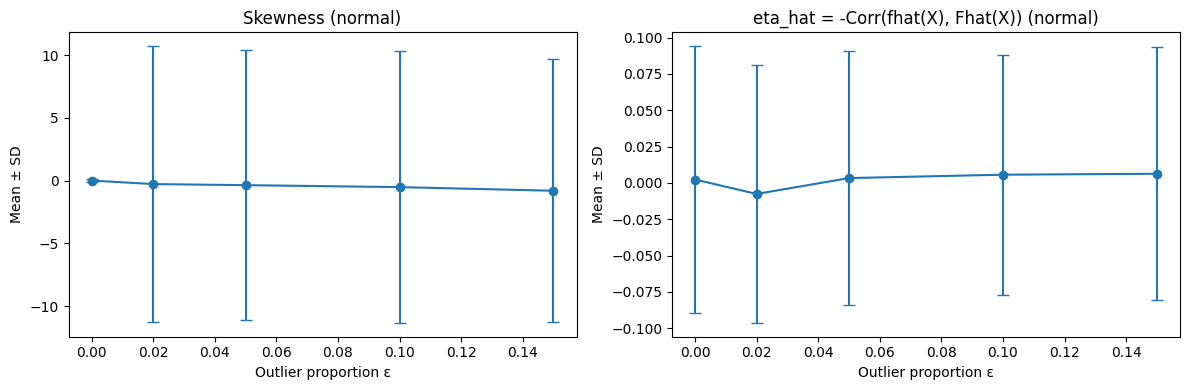

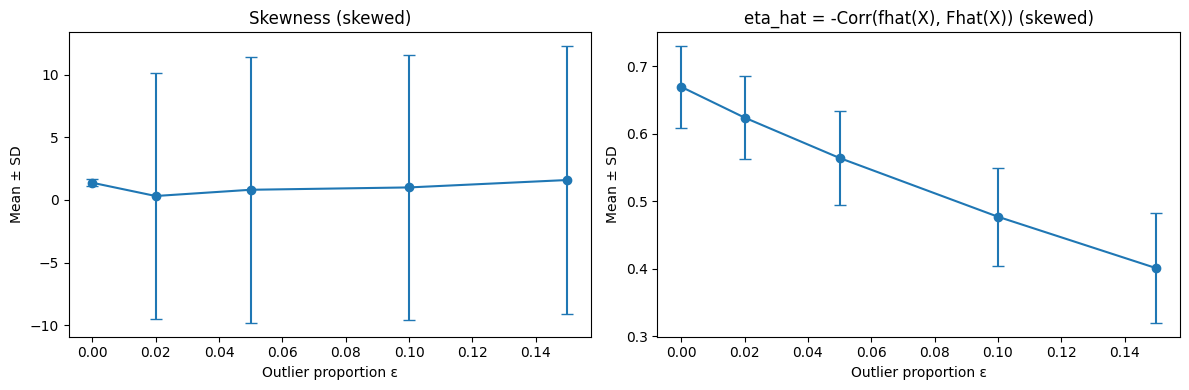

In [15]:
# normal baseline + Cauchy contamination
df_normal = simulation_study(
    n=300,
    n_rep=200,
    base_dist="normal",
    epsilons=[0.0, 0.02, 0.05, 0.10, 0.15],
    cauchy_scale=8.0
)

# skewed baseline + Cauchy contamination
df_skewed = simulation_study(
    n=300,
    n_rep=200,
    base_dist="skewed",
    epsilons=[0.0, 0.02, 0.05, 0.10, 0.15],
    cauchy_scale=8.0
)

df_all = pd.concat([df_normal, df_skewed], ignore_index=True)

summary = summarize_results(df_all)
print(summary)

plot_summary(summary, base_dist="normal")
plot_summary(summary, base_dist="skewed")